# CSC 380 HW\#3 (Spring 2026)

## **TO-DO (0)**: Write your name

In [1]:
# TensorFlow and tf.keras
import tensorflow as tf
import tensorflow.keras

# Helper libraries
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print(tf.__version__)

2.19.0


In [2]:
# ── Japanese font setup for matplotlib ───────────────────────
!apt-get install -y fonts-ipafont-gothic -qq

from matplotlib import font_manager

# Register the newly installed font
font_manager.fontManager.addfont(
    '/usr/share/fonts/truetype/fonts-japanese-gothic.ttf')

# Tell matplotlib to use it
matplotlib.rcParams['font.family'] = 'IPAGothic'

print("Japanese font ready:",
      matplotlib.rcParams['font.family'])

Selecting previously unselected package fonts-ipafont-gothic.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../fonts-ipafont-gothic_00303-21ubuntu1_all.deb ...
Unpacking fonts-ipafont-gothic (00303-21ubuntu1) ...
Selecting previously unselected package fonts-ipafont-mincho.
Preparing to unpack .../fonts-ipafont-mincho_00303-21ubuntu1_all.deb ...
Unpacking fonts-ipafont-mincho (00303-21ubuntu1) ...
Setting up fonts-ipafont-mincho (00303-21ubuntu1) ...
update-alternatives: using /usr/share/fonts/opentype/ipafont-mincho/ipam.ttf to provide /usr/share/fonts/truetype/fonts-japanese-mincho.ttf (fonts-japanese-mincho.ttf) in auto mode
Setting up fonts-ipafont-gothic (00303-21ubuntu1) ...
update-alternatives: using /usr/share/fonts/opentype/ipafont-gothic/ipag.ttf to provide /usr/share/fonts/truetype/fonts-japanese-gothic.ttf (fonts-japanese-gothic.ttf) in auto mode
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Japanese font ready: [

## 1. Load data

In [5]:
# Load data from course Github site
depo_url = "https://raw.githubusercontent.com/ntomuro/CSC380/main/HW3-Kuzushiji-46/"

# download data
!wget -O train.npz {depo_url}train.npz
!wget -O val.npz {depo_url}val.npz
!wget -O test.npz {depo_url}test.npz
!wget -O class_map.csv {depo_url}class_map.csv

# training data
train = np.load('train.npz')
X_train, y_train = train['images'], train['labels']   # (48300, 28, 28, 1) uint8
print(f'Training: x={X_train.shape}, y={y_train.shape}')
input_shape = X_train.shape[1:-1] # image shape - Global Variable
print (f'  input image shape={input_shape}')
num_classes = len(np.unique(y_train)) # number of classes - Global Variable
print (f'  num of classes={num_classes}')

# validation data
val   = np.load("val.npz")
X_val, y_val = val['images'], val['labels']
print(f'Validation: x={X_val.shape}, y={y_val.shape}') # (10350, 28, 28, 1)

# test data
test  = np.load("test.npz")
X_test = test['images']   # (10350, 28, 28, 1) — submit predictions for these
print(f'Test: x={X_test.shape}')

--2026-04-22 22:50:58--  https://raw.githubusercontent.com/ntomuro/CSC380/main/HW3-Kuzushiji-46/train.npz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14099381 (13M) [application/octet-stream]
Saving to: ‘train.npz’

train.npz           100%[===================>]  13.45M  --.-KB/s    in 0.09s   

2026-04-22 22:50:58 (149 MB/s) - ‘train.npz’ saved [14099381/14099381]

--2026-04-22 22:50:58--  https://raw.githubusercontent.com/ntomuro/CSC380/main/HW3-Kuzushiji-46/val.npz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3019707 (2.

## 2. Preprocess data

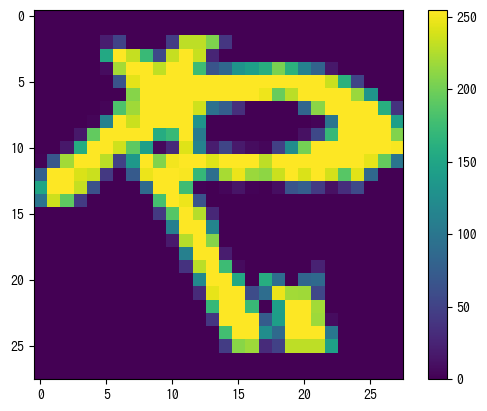

In [6]:
# first visualize a raw image (8x8, and each pixel between 0 and 255)
plt.figure()
plt.imshow(X_train[2])
plt.colorbar()
plt.grid(False)
plt.show()

### **TO-DO (1)**: Normalize images so that each pixel value will be a floating number and between 0.0 and 1.0 (by dividing by 255.0).

In [12]:
# TO-DO (1)
train_images = #YOU FILL IN HERE
val_images =   #YOU FILL IN HERE
test_images =  #YOU FILL IN HERE

train_labels = y_train
val_labels = y_val

### Some examples with (true) labels

In [13]:
import csv

def load_class_map(filepath):
    """
    Returns a dict mapping new label (0-45) → character info.
    Keys: 'label', 'original_index', 'codepoint', 'character'
    """
    class_map = {}
    with open(filepath, newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            label = int(row['label'])
            class_map[label] = {
                'original_index': int(row['original_index']),
                'codepoint':      row['codepoint'],
                'character':      row['character']
            }
    return class_map

# Call the function with the class map file
class_map = load_class_map(depo_url + 'class_map.csv')

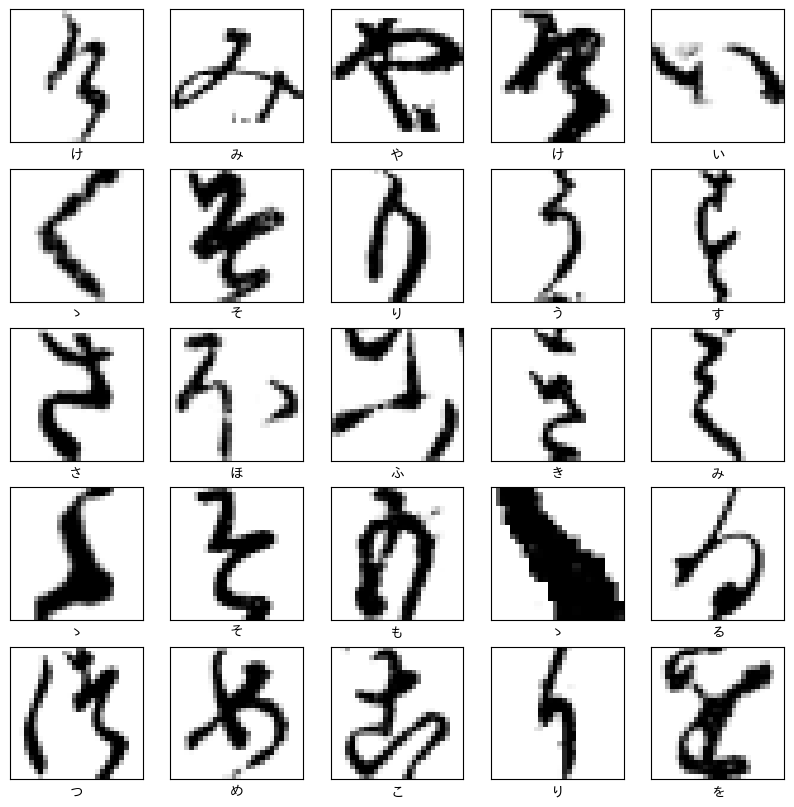

In [14]:
# Visualize some examples
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_map[y_train[i]]['character'])
plt.show()

## 3. Build/Define the model

We will use a multi-layer feed-forward network (also called MFFNN). The starter model is quite simple: input layer + one hidden layer + output layer.

In [16]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=input_shape), # input 28*28==784 gray pixels is made into 1-D array
    tf.keras.layers.Dense(128, activation='relu'), # a hidden layer with 128 nodes with activation function 'relu'
    tf.keras.layers.Dense(num_classes)  # DON'T CHANGE this line: output layer with the number of image classes (46)
])

## 4. Compile the model

Before the model is ready for training, it needs a few more settings. These are added during the model's compile step:
<ul>
<li><b>Optimizer</b> —This is how the model is updated based on the data it sees and its loss function.  Notable hyperparameters are <b>learning_rate</b> and <b>weight_decay</b>.
<li><b>Loss function</b> —This measures how accurate the model is during training. You want to minimize this function to "steer" the model in the right direction.
<li><b>Metrics</b> —Used to monitor the training and testing steps. The following example uses accuracy, the fraction of the images that are correctly classified.
</ul>

In [19]:
# learning rate can be overridden (from default 0.001 to whatever you like)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)#, my override
                                     #weight_decay=1e-6) #

model.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), # DON'T CHANGE this line
              metrics=['accuracy'])

## 5. Train the model

We train the model, using the training and validation data, with optimizer.  We can specify/override the number of epochs in the parameter too.

In [ ]:
history = model.fit(
    train_images, train_labels,
    validation_data=(val_images, val_labels), epochs=20) # you can train longer epochs too, of course.

### **TO-DO (2)**: Plot the performance that compares training vs. validation sets, on accuracy and loss.

In [ ]:
## TO-DO (2):
##  YOU FILL IN HERE

## 6. Make predictions

With the model trained, you can use it to make predictions on some images. Attach a **softmax layer** to convert the model's linear outputs—logits to **probabilities** (for each class), which should be easier to interpret.

In [21]:
# Add a softmax layer on the trained model
probability_model = tf.keras.Sequential([model, # trained model
                                         tf.keras.layers.Softmax()])

### 6.1 Generate predictions for the validation set first -- so that we can compare with the ground truth labels.

In [22]:
# Make predictions on the validation images
predictions = probability_model.predict(val_images)

324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [23]:
# Prediction (class probabilities) for one example validation image
idx = 5
predictions[idx] # an numpy array of 46 probabilities (which sum up to 1.0)

array([6.2095688e-07, 1.8738847e-10, 1.2558527e-08, 1.5997101e-09,
       3.6579463e-06, 6.4228147e-01, 6.5620490e-08, 7.1453374e-05,
       7.9478945e-05, 3.5212550e-01, 3.3746903e-05, 6.6696853e-06,
       7.4408126e-06, 7.4194513e-09, 6.3234789e-04, 4.2266716e-08,
       1.5741967e-06, 1.5891833e-07, 1.7879567e-05, 1.7269765e-03,
       2.7512849e-04, 3.4114251e-08, 5.9098622e-04, 1.0433820e-06,
       6.3591493e-08, 1.3497002e-07, 1.9243199e-08, 1.8016792e-05,
       3.1045624e-06, 1.9464864e-03, 7.0220977e-07, 3.8428871e-06,
       3.1805670e-05, 4.1082549e-06, 4.3162325e-07, 1.6308923e-06,
       1.7581716e-07, 1.7068890e-09, 2.4978069e-06, 3.1219774e-05,
       1.2217930e-06, 2.7679278e-06, 1.1754319e-06, 9.3583381e-05,
       7.1099918e-12, 6.9120301e-07], dtype=float32)

In [24]:
# Examine the predicted class vs. True class
pred_class = np.argmax(predictions[idx])
true_class = val_labels[idx]
print (f'Predicted class: {pred_class} ({class_map[pred_class]["character"]})')
print (f'True class: {true_class} ({class_map[true_class]["character"]})')

Predicted class: 5 (き)
True class: 9 (さ)


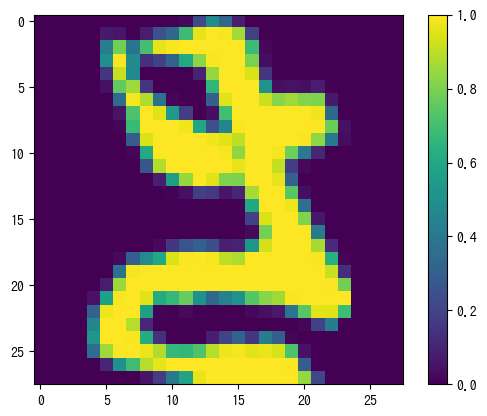

In [25]:
# Visualize the image
plt.figure()
plt.imshow(val_images[idx])
plt.colorbar()
plt.grid(False)
plt.show()

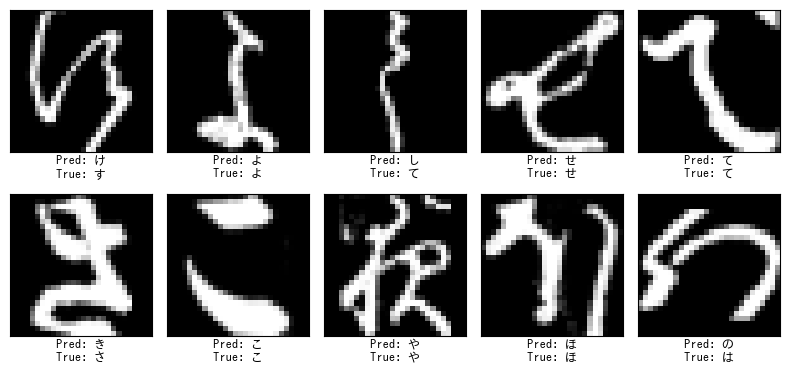

In [26]:
# More visualization (if you like)
fig, axes = plt.subplots(2, 5, figsize=(8, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(val_images[i], cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

    pred_class = np.argmax(predictions[i])
    true_class = val_labels[i]

    ax.set_xlabel(
        f"Pred: {class_map[pred_class]['character']}\n"
        f"True: {class_map[true_class]['character']}",
        fontsize=9,
        labelpad=2,
    )

plt.tight_layout()
plt.show()

### **TO-DO (3)**: 6.2 Generate predictions for the **TEST** images

In [ ]:
## TO-DO (3):
##  YOU FILL IN HERE

## **TO-DO (4)**: Write the test predictions in a file (for Kaggle submission).

In [ ]:
## TO-DO (4):
##  YOU FILL IN HERE